# Inférence statistique

> Modèles retenus : CatBoost, XGBoost, LightGBM (cible `log1p`) + Stacking OOF  
> Optimisation sur **MAPE** (au lieu de MAE) + feature engineering ciblé sur les petites valeurs.

## Imports & configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

# Manipulation de données
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import sys
import os


# Modèles
from sklearn.linear_model import LinearRegression

# Évaluation et validation
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)

from sklearn.inspection import permutation_importance

# Modèles de Gradient Boosting
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Optimisation d'hyperparamètres
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)



# On connecte le notebook à tous les fichiers inclus dans le dossier /fonctions
sys.path.insert(0, os.path.abspath("../fonctions"))

%load_ext autoreload
%autoreload 

RANDOM_STATE = 1308
N_TRIALS = 1

### A.2 : Chargement des données

Split **temporel** : train 2020-2022 / val 2023 / test 2024. On entraîne toujours sur le passé et on évalue sur le futur.

In [2]:
# Chargement des données

df_train = pd.read_csv("../data_finale/featuring/train_featured.csv")
df_val   = pd.read_csv("../data_finale/featuring/val_featured.csv")
df_test  = pd.read_csv("../data_finale/featuring/test_featured.csv")
df_en_cours = pd.read_csv("../data_finale/featuring/en_cours_featured.csv")

# On supprime les lignes avec des valeurs manquantes pour notre variable cible

colonne_cible  = "market_value_in_eur"

df_train = df_train.dropna(subset=[colonne_cible])
df_val   = df_val.dropna(subset=[colonne_cible])
df_test  = df_test.dropna(subset=[colonne_cible])
df_en_cours = df_en_cours.dropna(subset=[colonne_cible])

In [3]:
# Colonnes à supprimer pour l'entraînement

colonne_joueur = "player"
colonne_team   = "team"
colonne_nation = "nation"

cols_a_supprimer = [colonne_cible, colonne_joueur, colonne_team, colonne_nation, "position"]

X_train = df_train.drop(columns=cols_a_supprimer)
y_train = df_train[colonne_cible]

X_val = df_val.drop(columns=cols_a_supprimer)
y_val = df_val[colonne_cible]

X_test = df_test.drop(columns=cols_a_supprimer)
y_test = df_test[colonne_cible]

X_en_cours = df_en_cours.drop(columns=cols_a_supprimer)
y_en_cours = df_en_cours[colonne_cible]

In [4]:
# Préparation pour certains modèles : sélection dynamique des colonnes sans aucun NaN
colonnes_sans_nan = X_train.columns[X_train.isna().sum() == 0].tolist()

print(f"Filtrage pour les modèles linéaires/SVR :")
print(f"{len(colonnes_sans_nan)} colonnes conservées sur {X_train.shape[1]}.")

X_train_sans_nan = X_train[colonnes_sans_nan]
X_val_sans_nan   = X_val[colonnes_sans_nan]
X_test_sans_nan  = X_test[colonnes_sans_nan]
X_en_cours_sans_nan = X_en_cours[colonnes_sans_nan]

Filtrage pour les modèles linéaires/SVR :
142 colonnes conservées sur 151.


### A.3 : Feature engineering

#### `log_prev_value` = valeur marchande de l'année N-1

On calcule la valeur de la saison précédente. Comme on concatène les 3 splits avant le shift, la valeur 2023 d'un joueur provient de sa ligne 2022 (dans le train) : **aucune information future n'est utilisée**.

In [5]:
# Valeur marchande de la saison précédente

# On crée une base d'historique propre et triée par temps
df_history = pd.concat([df_train, df_val, df_test, df_en_cours], axis=0)
df_history = df_history.sort_values(["player", "season_year"])

# On calcule le shift sur cet historique de référence
df_history["log_prev_value"] = np.log1p(
    df_history.groupby("player")["market_value_in_eur"].shift(1)
)

# On redécoupe le dataset en train/val/test
df_train = df_history[df_history["season_year"].isin([2020, 2021, 2022])].copy()
df_val   = df_history[df_history["season_year"] == 2023].copy()
df_test  = df_history[df_history["season_year"] == 2024].copy()
df_en_cours = df_history[df_history["season_year"] == 2025].copy()

#### Imputation des NaN

Les médianes sont apprises **uniquement sur le train** (par ligue × position), puis appliquées à val et test.

In [6]:
# Les médianes sont apprises uniquement sur le train par ligue et position

# On liste toutes tes colonnes qui commencent par 'league_'
league_cols = [col for col in df_train.columns if col.startswith('league_')]

def extraire_nom_ligue(df):
    df_temp = df.copy()
    # Si le joueur a un '1' dans une colonne league, on extrait le nom, sinon 'Other'
    df_temp['league_name'] = df_temp[league_cols].idxmax(axis=1).where(df_temp[league_cols].max(axis=1) == 1, 'league_Other')
    return df_temp

# On crée des versions temporaires avec la colonne 'league_name'
df_train_temp = extraire_nom_ligue(df_train)


# log_prev_value par Ligue et position
prev_pos_league = (
    df_train_temp
    .groupby(["league_name", "position"])["log_prev_value"]
    .median()
)

# Médiane par position simple (en secours)
prev_pos_backup = (
    df_train_temp
    .groupby("position")["log_prev_value"]
    .median()
)

prev_global = df_train_temp["log_prev_value"].median()



def impute_features(df):
    # On génère la colonne temporaire pour mapper les données
    df_with_league = extraire_nom_ligue(df)
    
    # Sauvegarde de l'index d'origine pour la conversion en Série
    original_index = df_with_league.index    

    mapped_prev_value = (
        df_with_league.set_index(["league_name", "position"])
        .index.map(prev_pos_league)
        .to_series(index=original_index)
    )
    df_with_league["log_prev_value"] = df_with_league["log_prev_value"].fillna(mapped_prev_value)

    # Secours 1 : Par position simple
    df_with_league["log_prev_value"] = df_with_league["log_prev_value"].fillna(
        df_with_league["position"].map(prev_pos_backup)
    )

    # Secours 2 : Médiane globale
    df_with_league["log_prev_value"] = df_with_league["log_prev_value"].fillna(
        prev_global
    )

    
    # On supprime la colonne temporaire avant de renvoyer le DataFrame propre
    return df_with_league.drop(columns=['league_name'])


df_train = impute_features(df_train)
df_val   = impute_features(df_val)
df_test  = impute_features(df_test)
df_en_cours = impute_features(df_en_cours)

### A.4 : Préparation des jeux de données X / y

In [7]:
cols_a_supprimer = [
    colonne_cible, colonne_joueur, colonne_team, colonne_nation,
    "position"
]

# On supprime uniquement les colonnes qui existent réellement

# On supprime (ou non) les colonnes normalisées
cols_a_supprimer = [c for c in cols_a_supprimer if c in df_train.columns]
colonnes_nor = [c for c in df_train.columns if c.endswith("_nor")]

df_train = df_train.drop(columns=colonnes_nor, errors="ignore")
df_val   = df_val.drop(columns=colonnes_nor, errors="ignore")
df_test  = df_test.drop(columns=colonnes_nor, errors="ignore")
df_en_cours = df_en_cours.drop(columns=colonnes_nor, errors="ignore")

# Construction des datasets d'entraînement, validation et test
X_train = df_train.drop(columns=cols_a_supprimer)
y_train = df_train[colonne_cible]

X_val   = df_val.drop(columns=cols_a_supprimer)
y_val   = df_val[colonne_cible]

X_test  = df_test.drop(columns=cols_a_supprimer)
y_test  = df_test[colonne_cible]

X_en_cours  = df_en_cours.drop(columns=cols_a_supprimer)
y_en_cours  = df_en_cours[colonne_cible]

# Cibles log
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)
y_test_log  = np.log1p(y_test)
y_en_cours_log  = np.log1p(y_en_cours)

# Poids d'entraînement : sur-pondère les petites valeurs pour améliorer le MAPE
sample_weights_train = 1 / np.log1p(y_train)
sample_weights_train = sample_weights_train / sample_weights_train.mean()

print(f"X_train : {X_train.shape} | X_val : {X_val.shape} | X_test : {X_test.shape}")

X_train : (7404, 144) | X_val : (2431, 144) | X_test : (1751, 144)


### B2 : Comparaison des algorithmes (cible log)

**Ce qu'on teste :** quel algorithme, tuné avec Optuna, donne les meilleures performances ?

**Modèles comparés :** Random Forest, Extra Trees, XGBoost, LightGBM, CatBoost, SVR et ElasticNet.

**Objectif Optuna :** RMSE log. On entraîne sur `log1p(y)` et on retransforme avec `expm1` pour les métriques.

**Ce qui varie ici :** l'algorithme.  
**Ce qui reste fixe :** pipeline Bloc A, objectif RMSE log, `N_TRIALS = 75`, `sample_weight = 1/log1p(y)`.


#### B2.7 — Construction des modèles finaux

In [8]:
import json

with open("meilleurs_hyperparametres.json", "r") as f:
    params = json.load(f)

xgb_final = XGBRegressor(
    **params["XGBoost"],
    tree_method="hist", enable_categorical=True,
    objective="reg:squarederror",
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
lgbm_final = LGBMRegressor(
    **params["LightGBM"],
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
cat_final = CatBoostRegressor(
    **params["CatBoost"],
    bootstrap_type="Bernoulli",
    random_state=RANDOM_STATE, early_stopping_rounds=50, verbose=0
)

modeles_finaux = {
    "XGBoost (log)":   xgb_final,
    "LightGBM (log)":  lgbm_final,
    "CatBoost (log)":  cat_final,
}


def evaluer_log(nom, modele, X_tr, y_tr_log, X_ev, y_ev, w=None):
    fit_kwargs = {"sample_weight": w} if w is not None else {}
    if isinstance(modele, CatBoostRegressor):
        modele.fit(X_tr, y_tr_log, eval_set=(X_ev, np.log1p(y_ev)), verbose=False, **fit_kwargs)
    else:
        modele.fit(X_tr, y_tr_log, **fit_kwargs)
    preds = np.expm1(modele.predict(X_ev))
    mae   = mean_absolute_error(y_ev, preds)
    rmse  = np.sqrt(mean_squared_error(y_ev, preds))
    mape  = mean_absolute_percentage_error(y_ev, preds)
    r2    = r2_score(y_ev, preds)
    n, p  = len(y_ev), X_ev.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    print(f"  {nom:12s} | MAPE : {mape:.2%} | MAE : {mae:>12,.0f} € | R² : {r2:.4f} | R²adj : {r2_adj:.4f}")
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2, "R2 Ajusté": r2_adj}

print("Évaluation validation")
resultats_val = {}
for nom, modele in modeles_finaux.items():
    resultats_val[nom] = evaluer_log(nom, modele, X_train, y_train_log, X_val, y_val, w=sample_weights_train)

df_val_res = pd.DataFrame(resultats_val).T.sort_values("MAPE")
print("\nClassement validation (MAPE croissant) :")
print(df_val_res)

Évaluation validation
  XGBoost (log) | MAPE : 42.96% | MAE :    3,061,802 € | R² : 0.8921 | R²adj : 0.8853
  LightGBM (log) | MAPE : 42.55% | MAE :    3,031,337 € | R² : 0.8896 | R²adj : 0.8826
  CatBoost (log) | MAPE : 43.65% | MAE :    3,221,819 € | R² : 0.8777 | R²adj : 0.8700

Classement validation (MAPE croissant) :
                         MAE          RMSE      MAPE        R2  R2 Ajusté
LightGBM (log)  3.031337e+06  5.979884e+06  0.425458  0.889595   0.882641
XGBoost (log)   3.061802e+06  5.912795e+06  0.429598  0.892059   0.885259
CatBoost (log)  3.221819e+06  6.294290e+06  0.436534  0.877680   0.869975


In [9]:
print("Évaluation test")
resultats_test = {}
for nom, modele in modeles_finaux.items():
    resultats_test[nom] = evaluer_log(nom, modele, X_train, y_train_log, X_test, y_test, w=sample_weights_train)

df_test_res = pd.DataFrame(resultats_test).T.sort_values("MAPE")
print("\nClassement test (MAPE croissant) :")
print(df_test_res)

Évaluation test
  XGBoost (log) | MAPE : 41.25% | MAE :    3,333,169 € | R² : 0.8735 | R²adj : 0.8621
  LightGBM (log) | MAPE : 39.47% | MAE :    3,269,631 € | R² : 0.8727 | R²adj : 0.8612
  CatBoost (log) | MAPE : 40.81% | MAE :    3,436,613 € | R² : 0.8771 | R²adj : 0.8661

Classement test (MAPE croissant) :
                         MAE          RMSE      MAPE        R2  R2 Ajusté
LightGBM (log)  3.269631e+06  6.519763e+06  0.394704  0.872651   0.861233
CatBoost (log)  3.436613e+06  6.403587e+06  0.408075  0.877149   0.866134
XGBoost (log)   3.333169e+06  6.498361e+06  0.412538  0.873486   0.862142


In [10]:
print("Évaluation année en cours")
resultats_en_cours = {}
for nom, modele in modeles_finaux.items():
    resultats_en_cours[nom] = evaluer_log(nom, modele, X_train, y_train_log, X_en_cours, y_en_cours, w=sample_weights_train)

df_en_cours_res = pd.DataFrame(resultats_en_cours).T.sort_values("MAPE")
print("\nClassement en cours (MAPE croissant) :")
print(df_en_cours_res)

Évaluation année en cours
  XGBoost (log) | MAPE : 40.67% | MAE :    4,676,608 € | R² : 0.8144 | R²adj : 0.7932
  LightGBM (log) | MAPE : 39.36% | MAE :    4,461,842 € | R² : 0.8074 | R²adj : 0.7854
  CatBoost (log) | MAPE : 40.98% | MAE :    5,132,351 € | R² : 0.7603 | R²adj : 0.7329

Classement en cours (MAPE croissant) :
                         MAE          RMSE      MAPE        R2  R2 Ajusté
LightGBM (log)  4.461842e+06  8.756625e+06  0.393556  0.807383   0.785352
XGBoost (log)   4.676608e+06  8.595963e+06  0.406730  0.814386   0.793156
CatBoost (log)  5.132351e+06  9.767472e+06  0.409849  0.760345   0.732934


### B3 : Stacking OOF (XGBoost + LightGBM + CatBoost)

Le Stacking OOF combine les 3 meilleurs modèles boosting via un méta-modèle linéaire à coefficients positifs (combinaison convexe).

Les prédictions OOF garantissent que chaque exemple du train reçoit une prédiction issue d'un modèle qui ne l'a jamais vu, contrairement à un split fixe qui biaiserait les poids du méta-modèle.

#### B3.1 — Génération des prédictions OOF et construction du méta-modèle

In [11]:
import json
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

base_models = ["XGBoost (log)", "LightGBM (log)", "CatBoost (log)"]

# Charger le JSON
with open("meta_model_weights.json", "r") as f:
    meta_config = json.load(f)


meta = LinearRegression(positive=True)
# On réinjecte les poids
meta.coef_ = np.array([meta_config["weights"][nom] for nom in base_models])
meta.intercept_ = float(meta_config["intercept"])

print("Méta-modèle 'meta' reconstruit avec succès !")
print("Poids :", dict(zip(base_models, meta.coef_.round(3))))
print(f"Intercept : {meta.intercept_:,.2f} €")

# Entraîner les modèles de base
print("\nEntraînement des modèles de base...")
for nom in base_models:
    modele = modeles_finaux[nom]
    if isinstance(modele, CatBoostRegressor):
        modele.fit(X_train, y_train_log, eval_set=(X_val, y_val_log),
                   sample_weight=sample_weights_train, verbose=False)
    else:
        modele.fit(X_train, y_train_log, sample_weight=sample_weights_train)
    print(f"  {nom} : entraîné")

# Prédictions sur Val et Test (repassées en Euros)
preds_val_euros = {nom: np.expm1(modeles_finaux[nom].predict(X_val)) for nom in base_models}
preds_test_euros = {nom: np.expm1(modeles_finaux[nom].predict(X_test)) for nom in base_models}
preds_en_cours_euros = {nom: np.expm1(modeles_finaux[nom].predict(X_en_cours)) for nom in base_models}

X_meta_val = pd.DataFrame(preds_val_euros)
X_meta_test = pd.DataFrame(preds_test_euros)
X_meta_en_cours = pd.DataFrame(preds_en_cours_euros)


pred_val_stack = meta.predict(X_meta_val)
pred_test_stack = meta.predict(X_meta_test)
pred_en_cours_stack = meta.predict(X_meta_en_cours)

preds_val_log  = {nom: modeles_finaux[nom].predict(X_val)  for nom in base_models}
preds_test_log = {nom: modeles_finaux[nom].predict(X_test) for nom in base_models}
preds_en_cours_log = {nom: modeles_finaux[nom].predict(X_en_cours) for nom in base_models}

print("\n--- Prédictions du Stacking avec 'meta' calculées avec succès ! ---")

Méta-modèle 'meta' reconstruit avec succès !
Poids : {'XGBoost (log)': np.float64(0.228), 'LightGBM (log)': np.float64(0.439), 'CatBoost (log)': np.float64(0.399)}
Intercept : 325,826.55 €

Entraînement des modèles de base...
  XGBoost (log) : entraîné
  LightGBM (log) : entraîné
  CatBoost (log) : entraîné

--- Prédictions du Stacking avec 'meta' calculées avec succès ! ---


#### B3.2 — Comparaison Blend (moyenne) vs Stacking OOF

On compare deux stratégies d'assemblage :
- **Blend (moyenne simple)** : moyenne arithmétique des 3 prédictions : rapide mais sous-optimal
- **Stacking OOF** : méta-modèle linéaire à coefficients positifs : apprend les poids optimaux

In [12]:
# Blend 1 : moyenne simple
pred_val_moyenne  = X_meta_val.mean(axis=1)
pred_test_moyenne = X_meta_test.mean(axis=1)
pred_en_cours_moyenne = X_meta_en_cours.mean(axis=1)

print("Blend (moyenne simple)")
print(f"  Val  -> MAE : {mean_absolute_error(y_val, pred_val_moyenne):,.0f} € | R² : {r2_score(y_val, pred_val_moyenne):.4f}")
print(f"  Test -> MAE : {mean_absolute_error(y_test, pred_test_moyenne):,.0f} € | R² : {r2_score(y_test, pred_test_moyenne):.4f}")
print(f"  En cours -> MAE : {mean_absolute_error(y_en_cours, pred_en_cours_moyenne):,.0f} € | R² : {r2_score(y_en_cours, pred_en_cours_moyenne):.4f}")


# Moyenne simple (baseline de comparaison)
pred_val_moy  = X_meta_val.mean(axis=1)
pred_test_moy = X_meta_test.mean(axis=1)
pred_en_cours_moy = X_meta_en_cours.mean(axis=1)

print("\n=== Comparaison finale (Validation) ===")
for label, preds in [("Stacking OOF", pred_val_stack), ("Moyenne simple", pred_val_moy)]:
    print(f"  {label:15s} | MAPE : {mean_absolute_percentage_error(y_val, preds):.2%} | MAE : {mean_absolute_error(y_val, preds):>12,.0f} € | R² : {r2_score(y_val, preds):.4f}")

Blend (moyenne simple)
  Val  -> MAE : 2,983,108 € | R² : 0.8966
  Test -> MAE : 3,217,180 € | R² : 0.8838
  En cours -> MAE : 4,638,113 € | R² : 0.8054

=== Comparaison finale (Validation) ===
  Stacking OOF    | MAPE : 53.57% | MAE :    3,010,314 € | R² : 0.9010
  Moyenne simple  | MAPE : 42.22% | MAE :    2,983,108 € | R² : 0.8966


In [13]:
comparaison_blend = pd.DataFrame({
    "MAE Val": {
        "CatBoost (log) seul": mean_absolute_error(y_val,  np.expm1(modeles_finaux["CatBoost (log)"].predict(X_val))),
        "Blend (moyenne)":     mean_absolute_error(y_val,  pred_val_moyenne),
        "Blend (stacking OOF)":mean_absolute_error(y_val,  pred_val_stack),
    },
    "R2 Val": {
        "CatBoost (log) seul": r2_score(y_val,  np.expm1(modeles_finaux["CatBoost (log)"].predict(X_val))),
        "Blend (moyenne)":     r2_score(y_val,  pred_val_moyenne),
        "Blend (stacking OOF)":r2_score(y_val,  pred_val_stack),
    },
    "MAE Test": {
        "CatBoost (log) seul": mean_absolute_error(y_test, np.expm1(modeles_finaux["CatBoost (log)"].predict(X_test))),
        "Blend (moyenne)":     mean_absolute_error(y_test, pred_test_moyenne),
        "Blend (stacking OOF)":mean_absolute_error(y_test, pred_test_stack),
    },
    "R2 Test": {
        "CatBoost (log) seul": r2_score(y_test, np.expm1(modeles_finaux["CatBoost (log)"].predict(X_test))),
        "Blend (moyenne)":     r2_score(y_test, pred_test_moyenne),
        "Blend (stacking OOF)":r2_score(y_test, pred_test_stack),
    },
}).sort_values("MAE Test")

print(comparaison_blend)

                           MAE Val    R2 Val      MAE Test   R2 Test
Blend (moyenne)       2.983108e+06  0.896592  3.217180e+06  0.883836
Blend (stacking OOF)  3.010314e+06  0.901018  3.287452e+06  0.890824
CatBoost (log) seul   3.221819e+06  0.877680  3.461150e+06  0.874912


#### B3.3 — Analyse d'erreur par tranche de valeur

On décompose l'erreur du meilleur modèle par tranche de valeur marchande pour identifier où le modèle peine le plus.

In [14]:
meilleure_prediction_test = pred_test_stack

tranches       = [0, 5_000_000, 20_000_000, 50_000_000, np.inf]
labels_tranches= ["<5M€", "5-20M€", "20-50M€", ">50M€"]

df_erreur = pd.DataFrame({
    "y_reel": y_test.values,
    "y_pred": meilleure_prediction_test,
})
df_erreur["erreur_abs"] = (df_erreur["y_reel"] - df_erreur["y_pred"]).abs()
df_erreur["erreur_pct"] = df_erreur["erreur_abs"] / df_erreur["y_reel"]
df_erreur["tranche"]    = pd.cut(df_erreur["y_reel"], bins=tranches, labels=labels_tranches)

synthese_tranches = df_erreur.groupby("tranche", observed=True).agg(
    n_joueurs     =("y_reel",      "size"),
    valeur_moyenne=("y_reel",      "mean"),
    MAE           =("erreur_abs",  "mean"),
    MAPE          =("erreur_pct",  "mean"),
)
synthese_tranches["% du total joueurs"]          = synthese_tranches["n_joueurs"] / len(df_erreur) * 100
synthese_tranches["% de l'erreur absolue totale"]= (
    df_erreur.groupby("tranche", observed=True)["erreur_abs"].sum() / df_erreur["erreur_abs"].sum() * 100
)


print(synthese_tranches)

         n_joueurs  valeur_moyenne           MAE      MAPE  \
tranche                                                      
<5M€           817    2.413250e+06  1.026515e+06  0.774742   
5-20M€         586    1.178584e+07  3.529284e+06  0.312407   
20-50M€        285    3.222105e+07  6.404948e+06  0.205409   
>50M€           63    8.190476e+07  1.625548e+07  0.193352   

         % du total joueurs  % de l'erreur absolue totale  
tranche                                                    
<5M€              46.659052                     14.569406  
5-20M€            33.466591                     35.928463  
20-50M€           16.276413                     31.711360  
>50M€              3.597944                     17.790770  


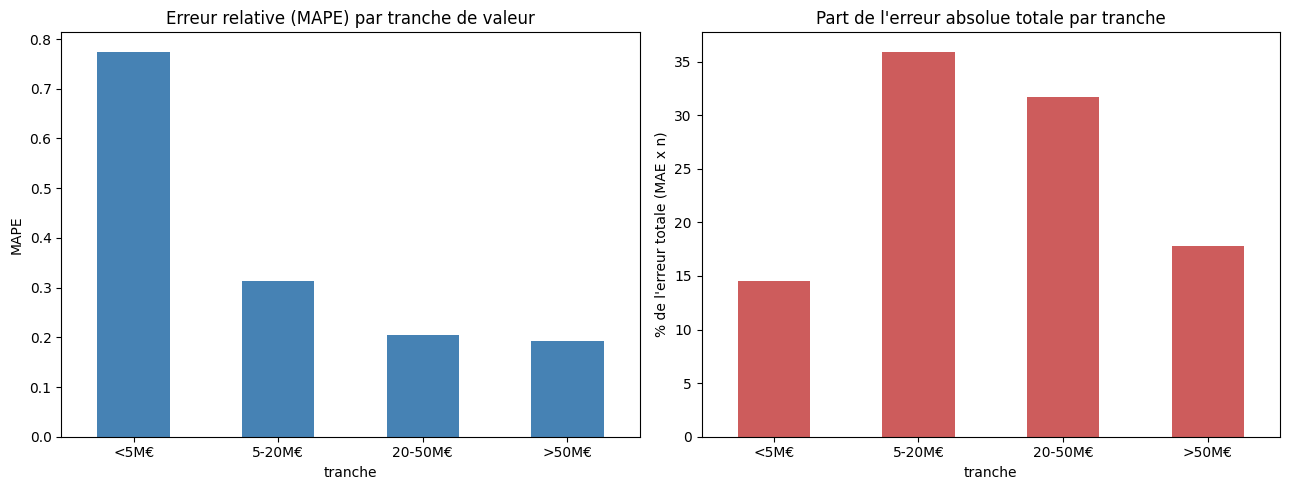

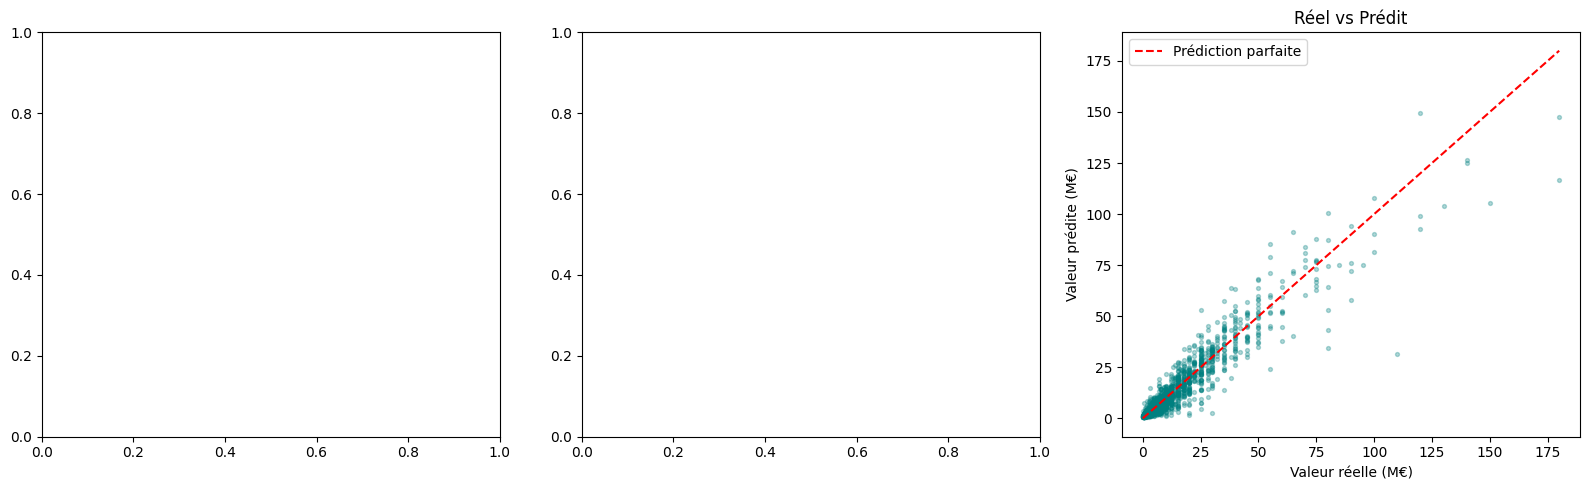

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

synthese_tranches["MAPE"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Erreur relative (MAPE) par tranche de valeur")
axes[0].set_ylabel("MAPE")
axes[0].tick_params(axis="x", rotation=0)

synthese_tranches["% de l'erreur absolue totale"].plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Part de l'erreur absolue totale par tranche")
axes[1].set_ylabel("% de l'erreur totale (MAE x n)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Valeurs réelles vs prédites
sample = df_erreur.sample(min(2000, len(df_erreur)), random_state=RANDOM_STATE)
axes[2].scatter(sample["y_reel"] / 1e6, sample["y_pred"] / 1e6, alpha=0.3, s=8, color="teal")
lim = max(sample["y_reel"].max(), sample["y_pred"].max()) / 1e6
axes[2].plot([0, lim], [0, lim], "r--", lw=1.5, label="Prédiction parfaite")
axes[2].set_xlabel("Valeur réelle (M€)")
axes[2].set_ylabel("Valeur prédite (M€)")
axes[2].set_title("Réel vs Prédit")
axes[2].legend()

plt.tight_layout()
plt.show()

#### B3.4 — Feature importance (CatBoost)

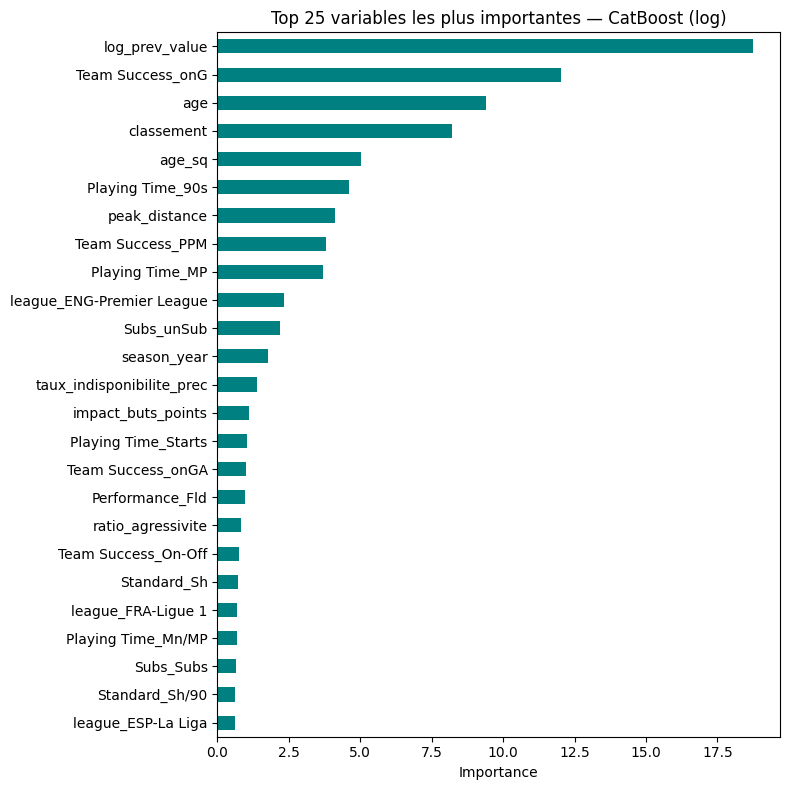

log_prev_value               18.755174
Team Success_onG             12.012343
age                           9.401580
classement                    8.209765
age_sq                        5.031956
Playing Time_90s              4.591367
peak_distance                 4.125396
Team Success_PPM              3.795294
Playing Time_MP               3.706554
league_ENG-Premier League     2.318098
Subs_unSub                    2.180603
season_year                   1.782159
taux_indisponibilite_prec     1.386529
impact_buts_points            1.117129
Playing Time_Starts           1.025854
Team Success_onGA             1.007298
Performance_Fld               0.981047
ratio_agressivite             0.815510
Team Success_On-Off           0.761777
Standard_Sh                   0.704357
league_FRA-Ligue 1            0.693328
Playing Time_Mn/MP            0.676186
Subs_Subs                     0.641555
Standard_Sh/90                0.629441
league_ESP-La Liga            0.596508
dtype: float64


In [16]:
importances = pd.Series(
    modeles_finaux["CatBoost (log)"].get_feature_importance(),
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
importances.head(25).sort_values().plot(kind="barh", color="teal")
plt.title("Top 25 variables les plus importantes — CatBoost (log)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(importances.head(25))

## Évaluation finale sur le TEST

> À lancer une seule fois, après avoir figé le choix du modèle sur la validation.

In [17]:
print("=== RÉSULTATS FINAUX (Test) ===")
resultats_test = {}
for label, preds in [
    ("Stacking OOF",  pred_test_stack),
    ("Moyenne simple",pred_test_moy),
    ("XGBoost seul",  np.expm1(preds_test_log["XGBoost (log)"])),
    ("LightGBM seul", np.expm1(preds_test_log["LightGBM (log)"])),
    ("CatBoost seul", np.expm1(preds_test_log["CatBoost (log)"])),
]:
    mae  = mean_absolute_error(y_test, preds)
    mape = mean_absolute_percentage_error(y_test, preds)
    r2   = r2_score(y_test, preds)
    n, p = len(y_test), X_test.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    resultats_test[label] = {"MAPE": mape, "MAE": mae, "R2": r2, "R2 Ajusté": r2_adj}
    print(f"  {label:15s} | MAPE : {mape:.2%} | MAE : {mae:>12,.0f} € | R² : {r2:.4f}")

df_test_final = pd.DataFrame(resultats_test).T.sort_values("MAPE")
print("\nClassement final (MAPE croissant) :")
print(df_test_final)

# Modèle retenu
meilleure_prediction_test = pred_test_stack

=== RÉSULTATS FINAUX (Test) ===
  Stacking OOF    | MAPE : 50.64% | MAE :    3,287,452 € | R² : 0.8908
  Moyenne simple  | MAPE : 39.62% | MAE :    3,217,180 € | R² : 0.8838
  XGBoost seul    | MAPE : 41.25% | MAE :    3,333,169 € | R² : 0.8735
  LightGBM seul   | MAPE : 39.47% | MAE :    3,269,631 € | R² : 0.8727
  CatBoost seul   | MAPE : 40.90% | MAE :    3,461,150 € | R² : 0.8749

Classement final (MAPE croissant) :
                    MAPE           MAE        R2  R2 Ajusté
LightGBM seul   0.394704  3.269631e+06  0.872651   0.861233
Moyenne simple  0.396210  3.217180e+06  0.883836   0.873420
CatBoost seul   0.409004  3.461150e+06  0.874912   0.863696
XGBoost seul    0.412538  3.333169e+06  0.873486   0.862142
Stacking OOF    0.506429  3.287452e+06  0.890824   0.881035


In [18]:
print("=== RÉSULTATS FINAUX (Année en cours) ===")
resultats_en_cours = {}
for label, preds in [
    ("Stacking OOF",  pred_en_cours_stack),
    ("Moyenne simple",pred_en_cours_moy),
    ("XGBoost seul",  np.expm1(preds_en_cours_log["XGBoost (log)"])),
    ("LightGBM seul", np.expm1(preds_en_cours_log["LightGBM (log)"])),
    ("CatBoost seul", np.expm1(preds_en_cours_log["CatBoost (log)"])),
]:
    mae  = mean_absolute_error(y_en_cours, preds)
    mape = mean_absolute_percentage_error(y_en_cours, preds)
    r2   = r2_score(y_en_cours, preds)
    n, p = len(y_en_cours), X_en_cours.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    resultats_en_cours[label] = {"MAPE": mape, "MAE": mae, "R2": r2, "R2 Ajusté": r2_adj}
    print(f"  {label:15s} | MAPE : {mape:.2%} | MAE : {mae:>12,.0f} € | R² : {r2:.4f}")

df_en_cours_final = pd.DataFrame(resultats_en_cours).T.sort_values("MAPE")
print("\nClassement final (MAPE croissant) :")
print(df_en_cours_final)

# Modèle retenu
meilleure_prediction_en_cours = pred_en_cours_stack

=== RÉSULTATS FINAUX (Année en cours) ===
  Stacking OOF    | MAPE : 42.80% | MAE :    4,364,074 € | R² : 0.8269
  Moyenne simple  | MAPE : 39.62% | MAE :    4,638,113 € | R² : 0.8054
  XGBoost seul    | MAPE : 40.67% | MAE :    4,676,608 € | R² : 0.8144
  LightGBM seul   | MAPE : 39.36% | MAE :    4,461,842 € | R² : 0.8074
  CatBoost seul   | MAPE : 40.92% | MAE :    5,105,186 € | R² : 0.7645

Classement final (MAPE croissant) :
                    MAPE           MAE        R2  R2 Ajusté
LightGBM seul   0.393556  4.461842e+06  0.807383   0.785352
Moyenne simple  0.396164  4.638113e+06  0.805408   0.783151
XGBoost seul    0.406730  4.676608e+06  0.814386   0.793156
CatBoost seul   0.409241  5.105186e+06  0.764547   0.737617
Stacking OOF    0.428039  4.364074e+06  0.826887   0.807087


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator
import shap



from sklearn.base import BaseEstimator, RegressorMixin


class StackingModel(BaseEstimator, RegressorMixin):

    def __init__(self, models, meta_model):
        self.models = models
        self.meta_model = meta_model

    def fit(self, X, y):
        # Pas besoin de réentraîner les modèles,
        # ils sont déjà entraînés dans ton notebook
        return self

    def predict(self, X):
        # Prédictions des modèles de niveau 1, repassées en euros (comme en cellule 17)
        X_meta = np.column_stack([
            np.expm1(model.predict(X)) for model in self.models
        ])

        # Le méta-modèle prédit directement en euros, pas besoin d'expm1 ensuite
        prediction_euros = self.meta_model.predict(X_meta)

        return prediction_euros



modele_stack = StackingModel(
    models=[
        modeles_finaux["XGBoost (log)"],
        modeles_finaux["LightGBM (log)"],
        modeles_finaux["CatBoost (log)"]
    ],
    meta_model=meta
)


print("--- PERMUTATION FEATURE IMPORTANCE ---")


result_perm = permutation_importance(
    modele_stack,
    X_val,
    y_val,
    scoring="neg_mean_absolute_percentage_error",
    n_repeats=1,
    random_state=1308,
    n_jobs=-1
)


# Organisation des résultats
sorted_idx = result_perm.importances_mean.argsort()[::-1]


perm_importances = pd.DataFrame(
    {
        "Feature": X_val.columns[sorted_idx],
        "Importance_Mean": -result_perm.importances_mean[sorted_idx],
        "Importance_Std": result_perm.importances_std[sorted_idx]
    }
)


print(perm_importances)

--- PERMUTATION FEATURE IMPORTANCE ---
                           Feature  Importance_Mean  Importance_Std
0                   log_prev_value        -0.817356             0.0
1                 Team Success_onG        -0.359877             0.0
2                              age        -0.225141             0.0
3                       classement        -0.137948             0.0
4        league_ENG-Premier League        -0.091051             0.0
..                             ...              ...             ...
139             indice_danger_tirs         0.001241             0.0
140             Per 90 Minutes_Gls         0.001616             0.0
141             classement_FIFA_10         0.001630             0.0
142                Performance_Off         0.002118             0.0
143  contribution_offensive_equipe         0.002779             0.0

[144 rows x 3 columns]


In [20]:
# Sélectionner les variables normalisées et créer la clé de jointure sans conflit
df_nor = perm_importances[perm_importances["Feature"].str.endswith("_nor")].copy()
df_nor["Cle_jointure"] = df_nor["Feature"].str.replace("_nor", "")

# Sélectionner les variables brutes correspondantes
df_brutes = perm_importances[perm_importances["Feature"].isin(df_nor["Cle_jointure"])].copy()

# Fusionner les deux DataFrames sur la clé commune
comparatif = pd.merge(
    df_brutes, 
    df_nor, 
    left_on="Feature", 
    right_on="Cle_jointure", 
    suffixes=("_brute", "_normalisee")
)

# Nettoyer et organiser l'affichage
comparatif = comparatif[[
    "Feature_brute", "Importance_Mean_brute", "Importance_Std_brute",
    "Feature_normalisee", "Importance_Mean_normalisee", "Importance_Std_normalisee"
]]

# Optionnel : Calculer la différence d'importance (Brute - Normalisée)
# Si > 0, la brute est plus importante. Si < 0, la normalisée l'emporte.
comparatif["Difference"] = comparatif["Importance_Mean_brute"] - comparatif["Importance_Mean_normalisee"]

print("--- COMPARAISON DES IMPORTANCES (BRUTE VS NORMALISÉE) ---")
print(comparatif.to_string(index=False))

# Définir la règle de décision
def prendre_decision(row):
    # Plus l'importance est élevée, plus la variable est utile.
    # (Note : la permutation importance avec neg_mean_absolute_percentage_error 
    # renvoie des valeurs positives après notre inversion par le signe moins (-) dans ton code d'origine)
    if abs(row["Importance_Mean_normalisee"]) > abs(row["Importance_Mean_brute"]):
        return "Conserver Normalisée"
    else:
        return "Garder Brute (Rejeter _nor)"

# Appliquer la décision sur chaque ligne
comparatif["Decision"] = comparatif.apply(prendre_decision, axis=1)

# Trier par importance pour voir les variables clés en premier
comparatif = comparatif.sort_values(by="Importance_Mean_normalisee", ascending=False)

# Affichage propre
print("--- BILAN ET DÉCISION PAR VARIABLE ---")
print(comparatif[[
    "Feature_brute", "Importance_Mean_brute", 
    "Feature_normalisee", "Importance_Mean_normalisee", 
    "Decision"
]].to_string(index=False))

--- COMPARAISON DES IMPORTANCES (BRUTE VS NORMALISÉE) ---
Empty DataFrame
Columns: [Feature_brute, Importance_Mean_brute, Importance_Std_brute, Feature_normalisee, Importance_Mean_normalisee, Importance_Std_normalisee, Difference]
Index: []
--- BILAN ET DÉCISION PAR VARIABLE ---
Empty DataFrame
Columns: [Feature_brute, Importance_Mean_brute, Feature_normalisee, Importance_Mean_normalisee, Decision]
Index: []


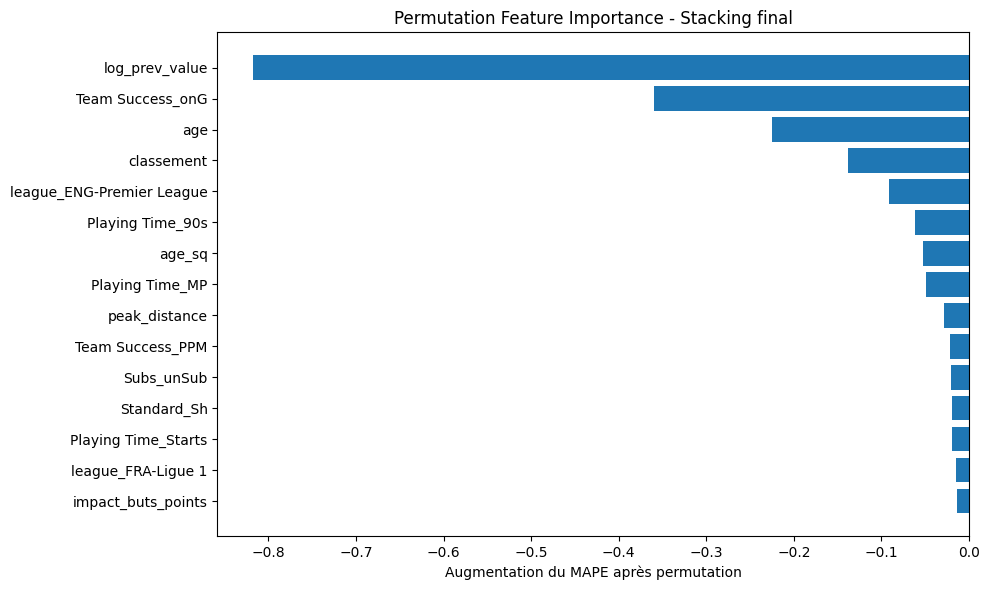


--- SHAP DU STACKING FINAL ---


Background dataset has 2431 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2431 when initializing the masker.


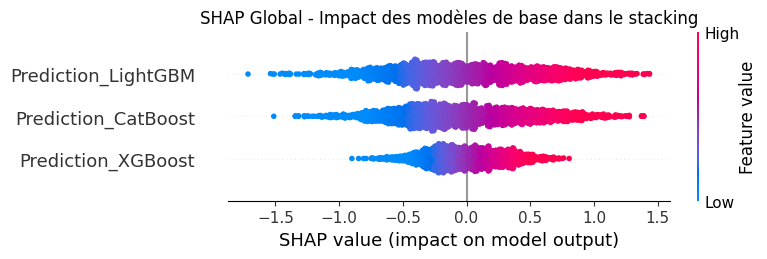

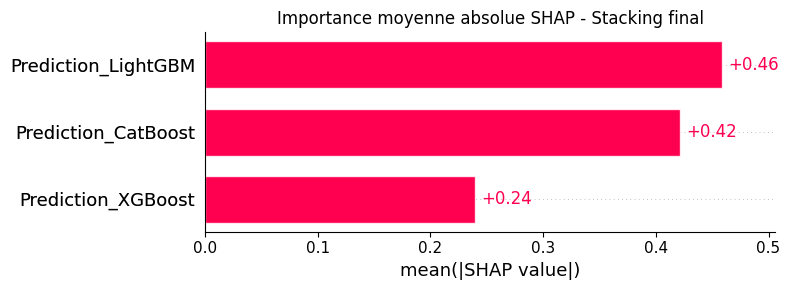


Explication locale de la première prédiction du jeu de validation


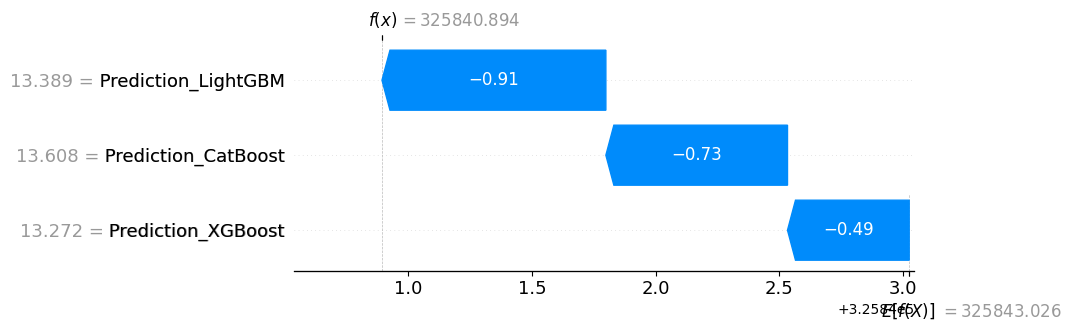

In [21]:
# Graphique
plt.figure(figsize=(10,6))

plt.barh(
    perm_importances["Feature"].head(15)[::-1],
    perm_importances["Importance_Mean"].head(15)[::-1],
    xerr=perm_importances["Importance_Std"].head(15)[::-1]
)

plt.xlabel("Augmentation du MAPE après permutation")
plt.title("Permutation Feature Importance - Stacking final")
plt.tight_layout()
plt.show()



print("\n--- SHAP DU STACKING FINAL ---")


# Le méta-modèle travaille sur les prédictions des modèles de base
X_meta_val = np.column_stack(
    [
        modeles_finaux["XGBoost (log)"].predict(X_val),
        modeles_finaux["LightGBM (log)"].predict(X_val),
        modeles_finaux["CatBoost (log)"].predict(X_val)
    ]
)


# Noms des variables du stacking
X_meta_val = pd.DataFrame(
    X_meta_val,
    columns=[
        "Prediction_XGBoost",
        "Prediction_LightGBM",
        "Prediction_CatBoost"
    ]
)


# Explainer adapté à LinearRegression
explainer = shap.LinearExplainer(
    meta,
    X_meta_val
)


shap_values = explainer(X_meta_val)



plt.figure(figsize=(10,6))

shap.plots.beeswarm(
    shap_values,
    max_display=10,
    show=False
)

plt.title(
    "SHAP Global - Impact des modèles de base dans le stacking"
)

plt.tight_layout()
plt.show()





plt.figure(figsize=(10,6))

shap.plots.bar(
    shap_values,
    max_display=10,
    show=False
)

plt.title(
    "Importance moyenne absolue SHAP - Stacking final"
)

plt.tight_layout()
plt.show()





print(
    "\nExplication locale de la première prédiction du jeu de validation"
)


shap.plots.waterfall(
    shap_values[0],
    max_display=10
)

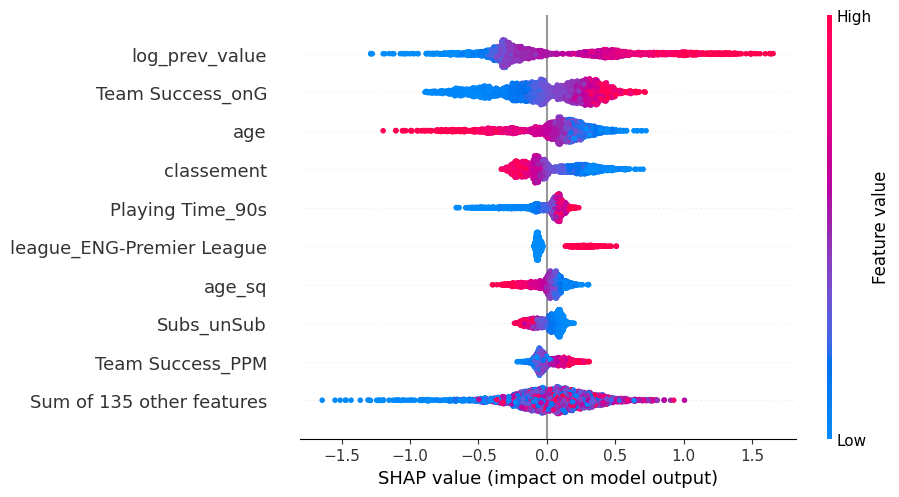

In [22]:
# Exemple sur XGBoost uniquement
explainer_xgb = shap.TreeExplainer(modeles_finaux["XGBoost (log)"])
shap_values_xgb = explainer_xgb(X_val)

shap.plots.beeswarm(shap_values_xgb)

refaire le même avec barres et sous-cas (exemple donné par Thibault)

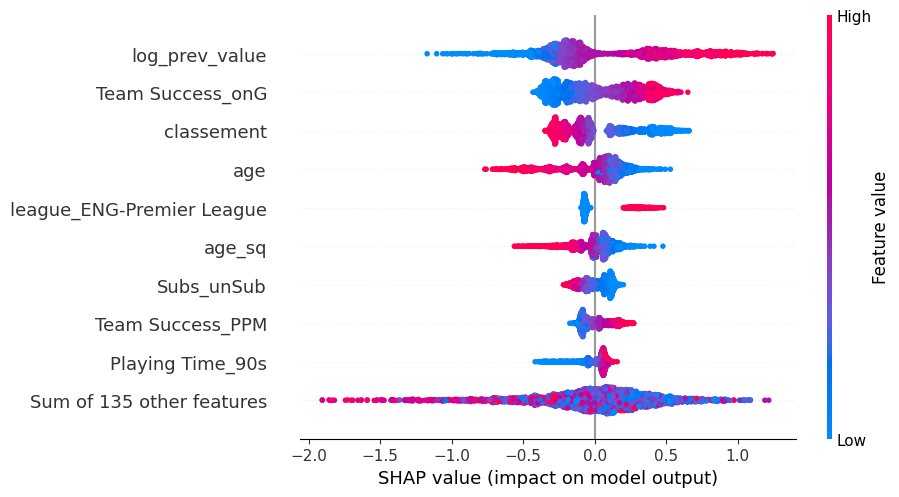

In [23]:
# Exemple sur CatBoost uniquement
explainer_cb = shap.TreeExplainer(modeles_finaux["CatBoost (log)"])
shap_values_cb = explainer_cb(X_val)

shap.plots.beeswarm(shap_values_cb)

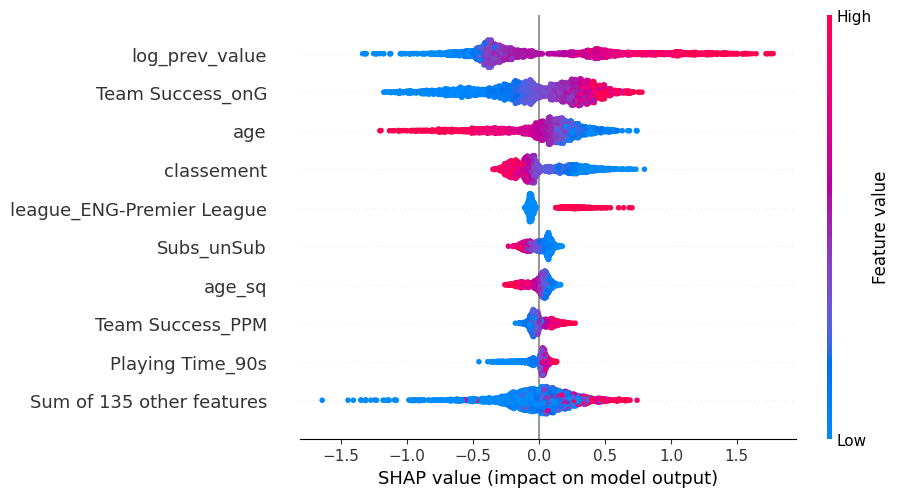

In [24]:
# Exemple sur LightGBM uniquement
explainer_lgb = shap.TreeExplainer(modeles_finaux["LightGBM (log)"])
shap_values_lgb = explainer_lgb(X_val)

shap.plots.beeswarm(shap_values_lgb)

PermutationExplainer explainer: 2it [00:10, 10.53s/it]               


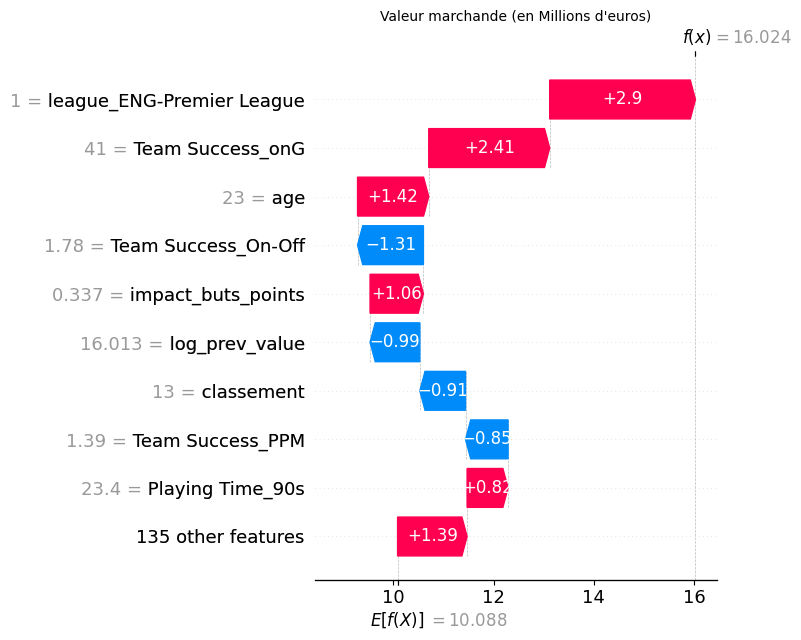

In [25]:
import numpy as np
import shap
import matplotlib.pyplot as plt

# Définition du modèle et des données
model_xgb = modeles_finaux["XGBoost (log)"]
indice_joueur = 200

# Fonction wrapper qui prédit directement en Millions d'euros
def predict_m_euro(X):
    # Passe du log(Prix) à l'Euro, puis en Millions
    return np.exp(model_xgb.predict(X)) / 1_000_000

# Création de l'explicateur SHAP sur la vraie valeur (€)
# On utilise un échantillon de fond (ex: 100 lignes) pour calculer les références
background_data = shap.sample(X_val, 100)
explainer_m_euro = shap.Explainer(predict_m_euro, background_data)

# Calcul des valeurs SHAP pour le joueur choisi
shap_values_m_euro = explainer_m_euro(X_val.iloc[[indice_joueur]])

# Affichage du waterfall
plt.figure(figsize=(9, 6))
shap.plots.waterfall(shap_values_m_euro[0], show=False)

plt.xlabel("Valeur marchande (en Millions d'euros)")
plt.tight_layout()
plt.show()

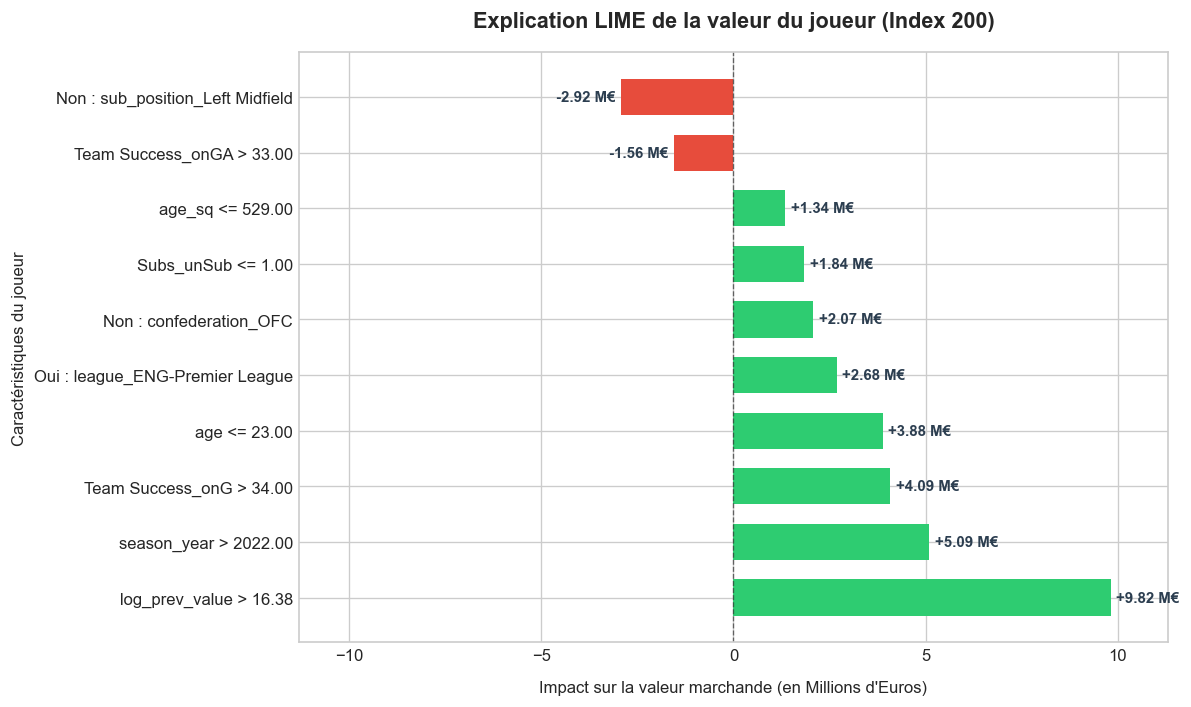

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import lime
import lime.lime_tabular


indice_joueur = 200


model = modeles_finaux["XGBoost (log)"]

# Imputation des NaN pour LIME
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# Fonction de prédiction en Millions d'Euros
def predict_m_euro(X):
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X, columns=X_train.columns)
    log_preds = model.predict(X)
    return np.exp(log_preds) / 1_000_000

# Création de l'explicateur LIME
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_imputed),
    feature_names=list(X_train.columns),
    class_names=['Valeur_M_Euro'],
    mode='regression',
    random_state=42
)

# Extraction des données du joueur choisi
joueur_data = X_test_imputed.iloc[indice_joueur].values

# Calcul de l'explication LIME
exp = explainer.explain_instance(
    data_row=joueur_data,
    predict_fn=predict_m_euro,
    num_features=10
)



# Extraction des données
list_exp = exp.as_list()
df_lime = pd.DataFrame(list_exp, columns=['Feature_Condition', 'Impact'])
df_lime = df_lime.sort_values(by='Impact', ascending=False)

# Nettoyage des étiquettes
def clean_feature_label(condition):
    if "<= 0.00" in condition:
        feat = condition.replace(" <= 0.00", "")
        return f"Non : {feat}"
    elif "> 0.00" in condition:
        feat = condition.replace(" > 0.00", "")
        return f"Oui : {feat}"
    return condition

df_lime['Pretty_Label'] = df_lime['Feature_Condition'].apply(clean_feature_label)
df_lime['Color'] = df_lime['Impact'].apply(lambda x: '#2ecc71' if x > 0 else '#e74c3c')

# Création de la figure
plt.figure(figsize=(10, 6), dpi=120)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

bars = plt.barh(
    y=df_lime['Pretty_Label'], 
    width=df_lime['Impact'], 
    color=df_lime['Color'],
    edgecolor='none',
    height=0.65
)

plt.axvline(x=0, color='#333333', linestyle='--', linewidth=0.8, alpha=0.7)

# Textes au bout des barres
for bar in bars:
    width = bar.get_width()
    x_pos = width + (0.15 if width > 0 else -0.15)
    ha = 'left' if width > 0 else 'right'
    
    plt.text(
        x_pos, 
        bar.get_y() + bar.get_height()/2, 
        f"{width:+.2f} M€", 
        va='center', 
        ha=ha, 
        fontsize=9, 
        fontweight='bold',
        color='#2c3e50'
    )

# Titre et axes
plt.title(f"Explication LIME de la valeur du joueur (Index {indice_joueur})", fontsize=13, pad=15, fontweight='bold')
plt.xlabel("Impact sur la valeur marchande (en Millions d'Euros)", fontsize=10, labelpad=10)
plt.ylabel("Caractéristiques du joueur", fontsize=10)

x_max = max(abs(df_lime['Impact'].min()), abs(df_lime['Impact'].max())) + 1.5
plt.xlim(-x_max, x_max)

plt.tight_layout()
plt.show()

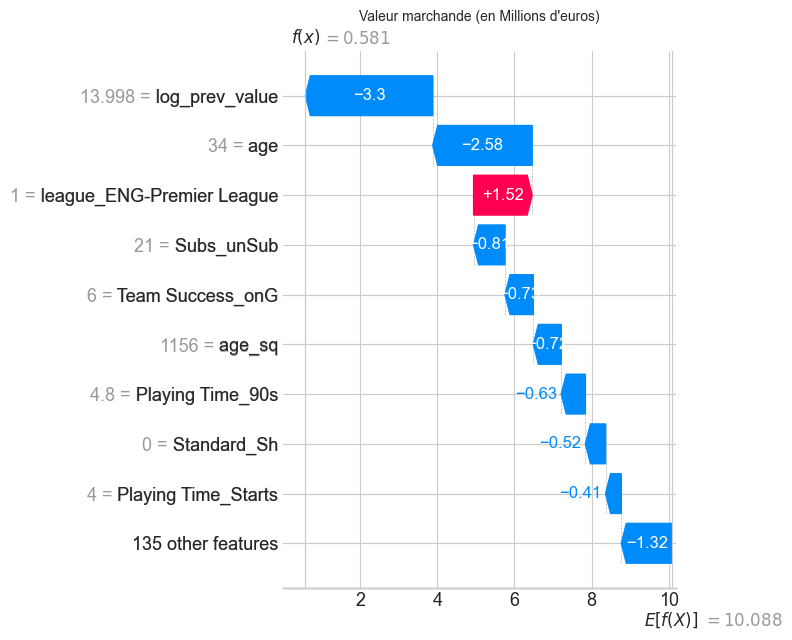

In [27]:
import numpy as np
import shap
import matplotlib.pyplot as plt

# Définition du modèle et des données
model_xgb = modeles_finaux["XGBoost (log)"]
indice_joueur = 0

# Fonction wrapper qui prédit directement en Millions d'euros
def predict_m_euro(X):
    # Passe du log(Prix) à l'Euro, puis en Millions
    return np.exp(model_xgb.predict(X)) / 1_000_000

# Création de l'explicateur SHAP sur la vraie valeur (€)
# On utilise un échantillon de fond (ex: 100 lignes) pour calculer les références
background_data = shap.sample(X_val, 100)
explainer_m_euro = shap.Explainer(predict_m_euro, background_data)

# Calcul des valeurs SHAP pour le joueur choisi
shap_values_m_euro = explainer_m_euro(X_val.iloc[[indice_joueur]])

# Affichage du waterfall
plt.figure(figsize=(9, 6))
shap.plots.waterfall(shap_values_m_euro[0], show=False)

plt.xlabel("Valeur marchande (en Millions d'euros)")
plt.tight_layout()
plt.show()

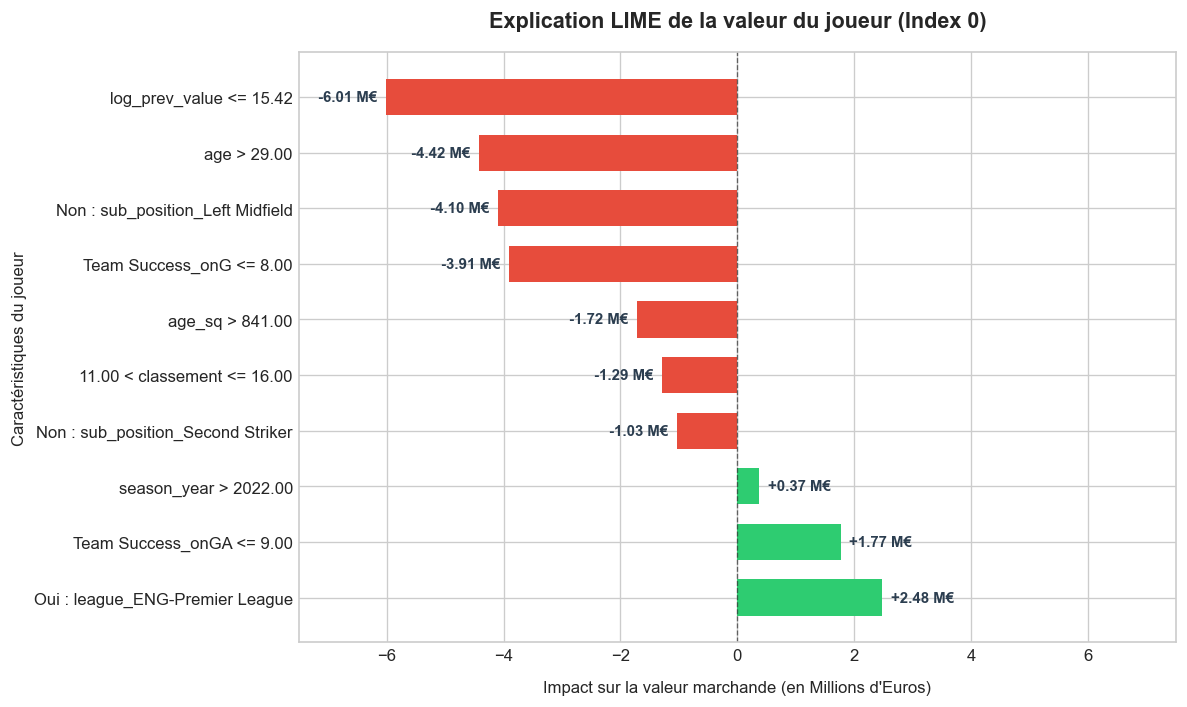

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import lime
import lime.lime_tabular


indice_joueur = 0


model = modeles_finaux["XGBoost (log)"]

# Imputation des NaN pour LIME
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# Fonction de prédiction en Millions d'Euros
def predict_m_euro(X):
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X, columns=X_train.columns)
    log_preds = model.predict(X)
    return np.exp(log_preds) / 1_000_000

# Création de l'explicateur LIME
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_imputed),
    feature_names=list(X_train.columns),
    class_names=['Valeur_M_Euro'],
    mode='regression',
    random_state=42
)

# Extraction des données du joueur choisi
joueur_data = X_test_imputed.iloc[indice_joueur].values

# Calcul de l'explication LIME
exp = explainer.explain_instance(
    data_row=joueur_data,
    predict_fn=predict_m_euro,
    num_features=10
)



# Extraction des données
list_exp = exp.as_list()
df_lime = pd.DataFrame(list_exp, columns=['Feature_Condition', 'Impact'])
df_lime = df_lime.sort_values(by='Impact', ascending=False)

# Nettoyage des étiquettes
def clean_feature_label(condition):
    if "<= 0.00" in condition:
        feat = condition.replace(" <= 0.00", "")
        return f"Non : {feat}"
    elif "> 0.00" in condition:
        feat = condition.replace(" > 0.00", "")
        return f"Oui : {feat}"
    return condition

df_lime['Pretty_Label'] = df_lime['Feature_Condition'].apply(clean_feature_label)
df_lime['Color'] = df_lime['Impact'].apply(lambda x: '#2ecc71' if x > 0 else '#e74c3c')

# Création de la figure
plt.figure(figsize=(10, 6), dpi=120)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

bars = plt.barh(
    y=df_lime['Pretty_Label'], 
    width=df_lime['Impact'], 
    color=df_lime['Color'],
    edgecolor='none',
    height=0.65
)

plt.axvline(x=0, color='#333333', linestyle='--', linewidth=0.8, alpha=0.7)

# Textes au bout des barres
for bar in bars:
    width = bar.get_width()
    x_pos = width + (0.15 if width > 0 else -0.15)
    ha = 'left' if width > 0 else 'right'
    
    plt.text(
        x_pos, 
        bar.get_y() + bar.get_height()/2, 
        f"{width:+.2f} M€", 
        va='center', 
        ha=ha, 
        fontsize=9, 
        fontweight='bold',
        color='#2c3e50'
    )

# Titre et axes
plt.title(f"Explication LIME de la valeur du joueur (Index {indice_joueur})", fontsize=13, pad=15, fontweight='bold')
plt.xlabel("Impact sur la valeur marchande (en Millions d'Euros)", fontsize=10, labelpad=10)
plt.ylabel("Caractéristiques du joueur", fontsize=10)

x_max = max(abs(df_lime['Impact'].min()), abs(df_lime['Impact'].max())) + 1.5
plt.xlim(-x_max, x_max)

plt.tight_layout()
plt.show()